<a href="https://colab.research.google.com/github/Elvin100s/time-series-pipeline/blob/main/Group1_Formative_1_pipeline_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative 1: Time Series Data Pipeline
**Group 1**  Machine Learning Pipeline   5th July 2026

**Team:** Elvin Cyubahiro · Samuel Rurangamirwa · Heroine Mutumwinka · Singizwa Homere

**Notebook maintained by:** Elvin Cyubahiro

GitHub repository: [REPO URL]

### Who Did What
*   **Elvin Cyubahiro:** Lead for Task 1C (Modeling). Responsible for advanced feature engineering (cyclical time encodings, multi-horizon lags, rolling statistics), model training pipeline (XGBoost/Random Forest), hyperparameter tuning, and model serialization.
*   **Singizwa Homere:** Lead for Task 1 (A–B) — Exploratory Data Analysis & Preprocessing. Dataset profiling, missing-value and outlier analysis, and the five analytical questions (Q1–Q5) with visualizations and interpretations, including lagged features and moving-average analyses.
*   **Heroine Mutumwinka:** Lead for Task 2 — Databases. MySQL schema design (3 tables with ERD and indexes), data seeding, and 3 SQL queries; MongoDB collection design, document insertion, and 3 aggregation queries.
*   **Samuel Rurangamirwa:** Lead for Tasks 3 & 4 — API & Prediction Pipeline. Flask REST API with 12 CRUD and time-series endpoints across MySQL and MongoDB, endpoint validation, and the predict.py end-to-end forecast script.

---

# Building a Pipeline for Time Series Data
## Power Consumption of Tétouan City, Morocco

**Dataset:** [Power Consumption of Tetouan City](https://www.kaggle.com/datasets/fedesoriano/electric-power-consumption) — Kaggle / [UCI ML Repository](https://archive.ics.uci.edu/dataset/849/power+consumption+of+tetouan+city)

**Description:** 52,416 observations recorded every 10 minutes across three distribution zones (Quads, Smir, Boussafou) in Tétouan, northern Morocco. Includes weather variables and solar diffuse flow measurements. Full year 2017.

The dataset is loaded programmatically using `kagglehub`, which handles authentication and caching automatically in Google Colab.

**Prediction Target:** Total power consumption (sum of all three zones)

---

### Contents
1. **Task 1** — Time-Series Preprocessing & Exploratory Analysis
2. **Task 2** — Database Design (SQL & MongoDB)
3. **Task 3** — CRUD Endpoints for Time-Series Queries
4. **Task 4** — Prediction / Forecast Script

---
# Task 1: Time-Series Preprocessing and Exploratory Analysis

## 1.1 Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')
sns.set_palette('deep')
print("Libraries loaded.")

Libraries loaded.


In [2]:
!pip install -q kagglehub

import kagglehub
import os, glob

# NOTE: kagglehub needs Kaggle API credentials to download.
# In Colab: Settings (gear icon, left sidebar) -> Secrets -> add KAGGLE_USERNAME and KAGGLE_KEY
#   (get these from kaggle.com/settings -> API -> Create New Token, opens a kaggle.json file
#    containing both values)
# Then uncomment the 3 lines below to load them into the environment:

# from google.colab import userdata
# os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
# os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

try:
    path = kagglehub.dataset_download("fedesoriano/electric-power-consumption")
    print("Downloaded to:", path)
    csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
    print("CSV files found:", csv_files)
    CSV_PATH = csv_files[0]
    print("Using:", CSV_PATH)
except Exception as e:
    print("kagglehub download failed:", e)
    print("Run the fallback cell below instead.")
    CSV_PATH = None

Using Colab cache for faster access to the 'electric-power-consumption' dataset.
Downloaded to: /kaggle/input/electric-power-consumption
CSV files found: ['/kaggle/input/electric-power-consumption/powerconsumption.csv']
Using: /kaggle/input/electric-power-consumption/powerconsumption.csv


In [3]:
import os
if 'CSV_PATH' not in dir() or not os.path.exists(CSV_PATH):
    print("Falling back to GitHub mirror (no Kaggle auth needed)...")
    CSV_PATH = 'powerconsumption.csv'
    !wget -q -O {CSV_PATH} "https://raw.githubusercontent.com/sunny2309/datasets/master/Tetuan%20City%20power%20consumption.csv"
    print("Downloaded to:", CSV_PATH)
else:
    print("kagglehub download already succeeded, skipping fallback.")

kagglehub download already succeeded, skipping fallback.


In [4]:
df = pd.read_csv(CSV_PATH)

# Clean column names defensively (strip whitespace, handle BOM)
df.columns = [str(c).strip().replace('\ufeff', '') for c in df.columns]
print("Raw columns:", list(df.columns))

# Find the datetime column regardless of exact name/case
dt_col = next((c for c in df.columns if c.lower() in
               ('datetime', 'date_time', 'date', 'timestamp')), df.columns[0])
print("Detected datetime column:", dt_col)

df[dt_col] = pd.to_datetime(df[dt_col])
df = df.rename(columns={dt_col: 'DateTime'}).set_index('DateTime').sort_index()

# Sanity check: dataset should have exactly 8 remaining feature columns
assert df.shape[1] == 8, "Expected 8 feature columns, got {}: {}".format(df.shape[1], list(df.columns))

df.columns = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows',
              'DiffuseFlows', 'Zone1', 'Zone2', 'Zone3']
df['TotalConsumption'] = df['Zone1'] + df['Zone2'] + df['Zone3']

print("Shape:", df.shape)
print("Range:", df.index.min(), "to", df.index.max())
df.head()

Raw columns: ['Datetime', 'Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows', 'PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']
Detected datetime column: Datetime
Shape: (52416, 9)
Range: 2017-01-01 00:00:00 to 2017-12-30 23:50:00


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,Zone1,Zone2,Zone3,TotalConsumption
DateTime,,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,70425.53544
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,69320.84387
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,67803.22193
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,65489.23209
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,63650.44627


> **Section lead:** Singizwa Homere — Task 1 (A–B). Dataset profiling, missing-value and outlier analysis, and analytical questions Q1–Q5 with visualizations and interpretations (see commit history in the repository).

## Part A: Understanding the Dataset

In [5]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print("Time Range:   ", df.index.min(), "->", df.index.max())
print("Duration:     ", (df.index.max() - df.index.min()).days, "days")
print("Records:      ", len(df))
print("Columns:      ", df.shape[1])
print("Granularity:   10-minute intervals (144/day)")

diffs = df.index.to_series().diff().dropna()
print()
print("Most common interval:", diffs.mode()[0])
irregular = diffs[diffs != pd.Timedelta('10min')]
print("Irregular intervals: ", len(irregular),
      "({:.2f}%)".format(len(irregular)/len(diffs)*100))

DATASET OVERVIEW
Time Range:    2017-01-01 00:00:00 -> 2017-12-30 23:50:00
Duration:      363 days
Records:       52416
Columns:       9
Granularity:   10-minute intervals (144/day)

Most common interval: 0 days 00:10:00
Irregular intervals:  0 (0.00%)


### A.2 Missing Values

In [6]:
missing = df.isnull().sum()
print(pd.DataFrame({'Count': missing, '%': (missing/len(df)*100)}).to_string())
print()
if missing.sum() == 0:
    print("No missing values. No imputation needed.")
else:
    df = df.ffill()
    print("Forward-filled missing values.")

                     Count    %
Temperature              0  0.0
Humidity                 0  0.0
WindSpeed                0  0.0
GeneralDiffuseFlows      0  0.0
DiffuseFlows             0  0.0
Zone1                    0  0.0
Zone2                    0  0.0
Zone3                    0  0.0
TotalConsumption         0  0.0

No missing values. No imputation needed.


### A.3 Data Types & Duplicates

In [7]:
print(df.dtypes.to_string())
print()
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate timestamps:", df.index.duplicated().sum())

Temperature            float64
Humidity               float64
WindSpeed              float64
GeneralDiffuseFlows    float64
DiffuseFlows           float64
Zone1                  float64
Zone2                  float64
Zone3                  float64
TotalConsumption       float64

Duplicate rows: 0
Duplicate timestamps: 0


### A.4 Statistical Distributions

### A.4 Statistical Distributions

In [8]:
desc = df.describe().T
desc['skew'] = df.skew()
desc['kurtosis'] = df.kurtosis()
desc[['mean','std','min','25%','50%','75%','max','skew','kurtosis']]

,mean,std,min,25%,50%,75%,max,skew,kurtosis
Temperature,18.810024,5.815476,3.247000,14.410000,18.780000,22.890000,40.01000,0.196719,-0.303321
Humidity,68.259518,15.551177,11.340000,58.310000,69.860000,81.400000,94.80000,-0.625166,-0.121860
WindSpeed,1.959489,2.348862,0.050000,0.078000,0.086000,4.915000,6.48300,0.462423,-1.783169
GeneralDiffuseFlows,182.696614,264.400960,0.004000,0.062000,5.035500,319.600000,1163.00000,1.306973,0.402768
DiffuseFlows,75.028022,124.210949,0.011000,0.122000,4.456000,101.000000,936.00000,2.456907,7.002902
Zone1,32344.970564,7130.562564,13895.696200,26310.668692,32265.920340,37309.018185,52204.39512,0.228864,-0.754054
Zone2,21042.509082,5201.465892,8560.081466,16980.766032,20823.168405,24713.717520,37408.86076,0.328876,-0.437397
Zone3,17835.406218,6622.165099,5935.174070,13129.326630,16415.117470,21624.100420,47598.32636,1.023871,1.086393
TotalConsumption,71222.885864,17143.138964,36785.039739,56499.074640,69788.790940,83749.172310,134208.14595,0.518854,-0.232507


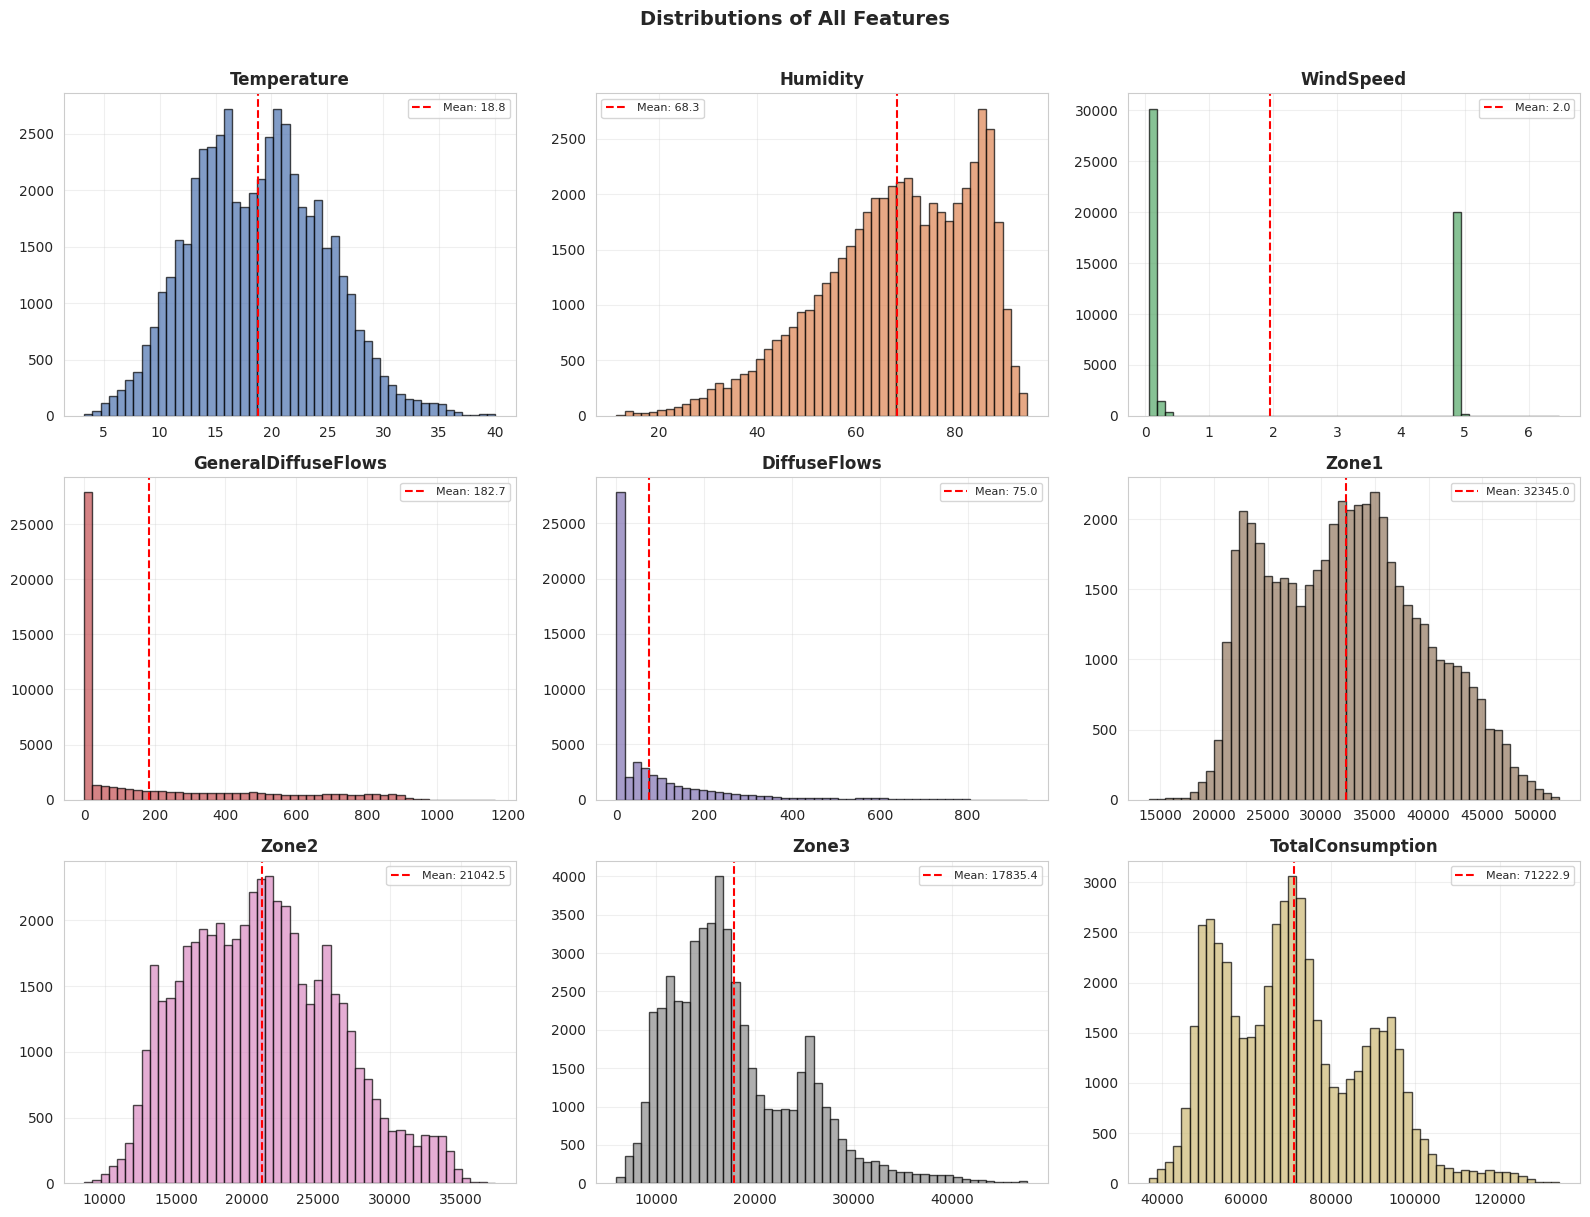

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for i, col in enumerate(df.columns):
    ax = axes.flat[i]
    ax.hist(df[col], bins=50, edgecolor='black', alpha=0.7,
            color=sns.color_palette()[i % 10])
    ax.set_title(col, fontweight='bold')
    m = df[col].mean()
    ax.axvline(m, color='red', ls='--', lw=1.5, label='Mean: {:.1f}'.format(m))
    ax.legend(fontsize=8)
plt.suptitle('Distributions of All Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

**Interpretation:**
- **Temperature** ≈ normal around 19 °C (Mediterranean climate).
- **Humidity** left-skewed (>55 % most of the time — coastal).
- **Wind Speed** & **Diffuse Flows** strongly right-skewed (night zeros + daytime peaks).
- **Zone 1** has the highest consumption; **Zone 3** shows a bimodal pattern.

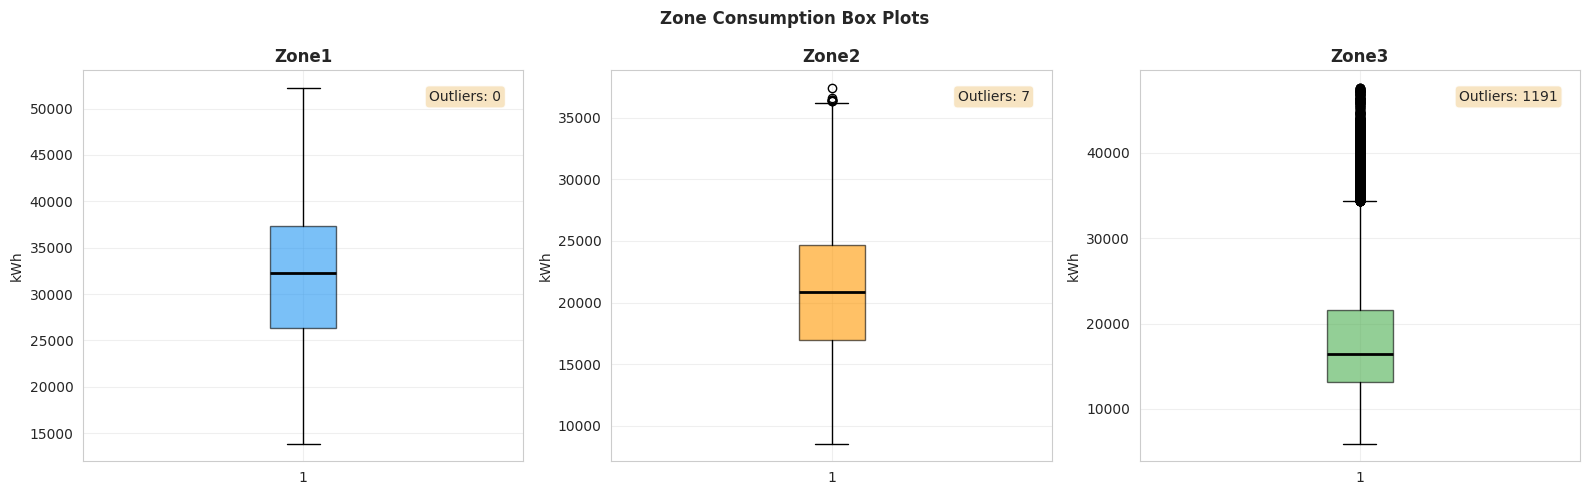

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (col, color) in enumerate(zip(['Zone1','Zone2','Zone3'],
                                      ['#2196F3','#FF9800','#4CAF50'])):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='black', lw=2))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('kWh')
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    axes[i].text(0.95, 0.95, 'Outliers: {}'.format(n_out),
                 transform=axes[i].transAxes, ha='right', va='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.suptitle('Zone Consumption Box Plots', fontweight='bold')
plt.tight_layout(); plt.show()

**Outlier Decision:** These are genuine peak-demand events (heat waves, industrial spikes), not measurement errors. Retaining them preserves the model's ability to predict extreme demand.

---
## Part B: Analytical Questions

Five questions; at least two use lagged features / moving averages.

### Q1 — Seasonal Trend

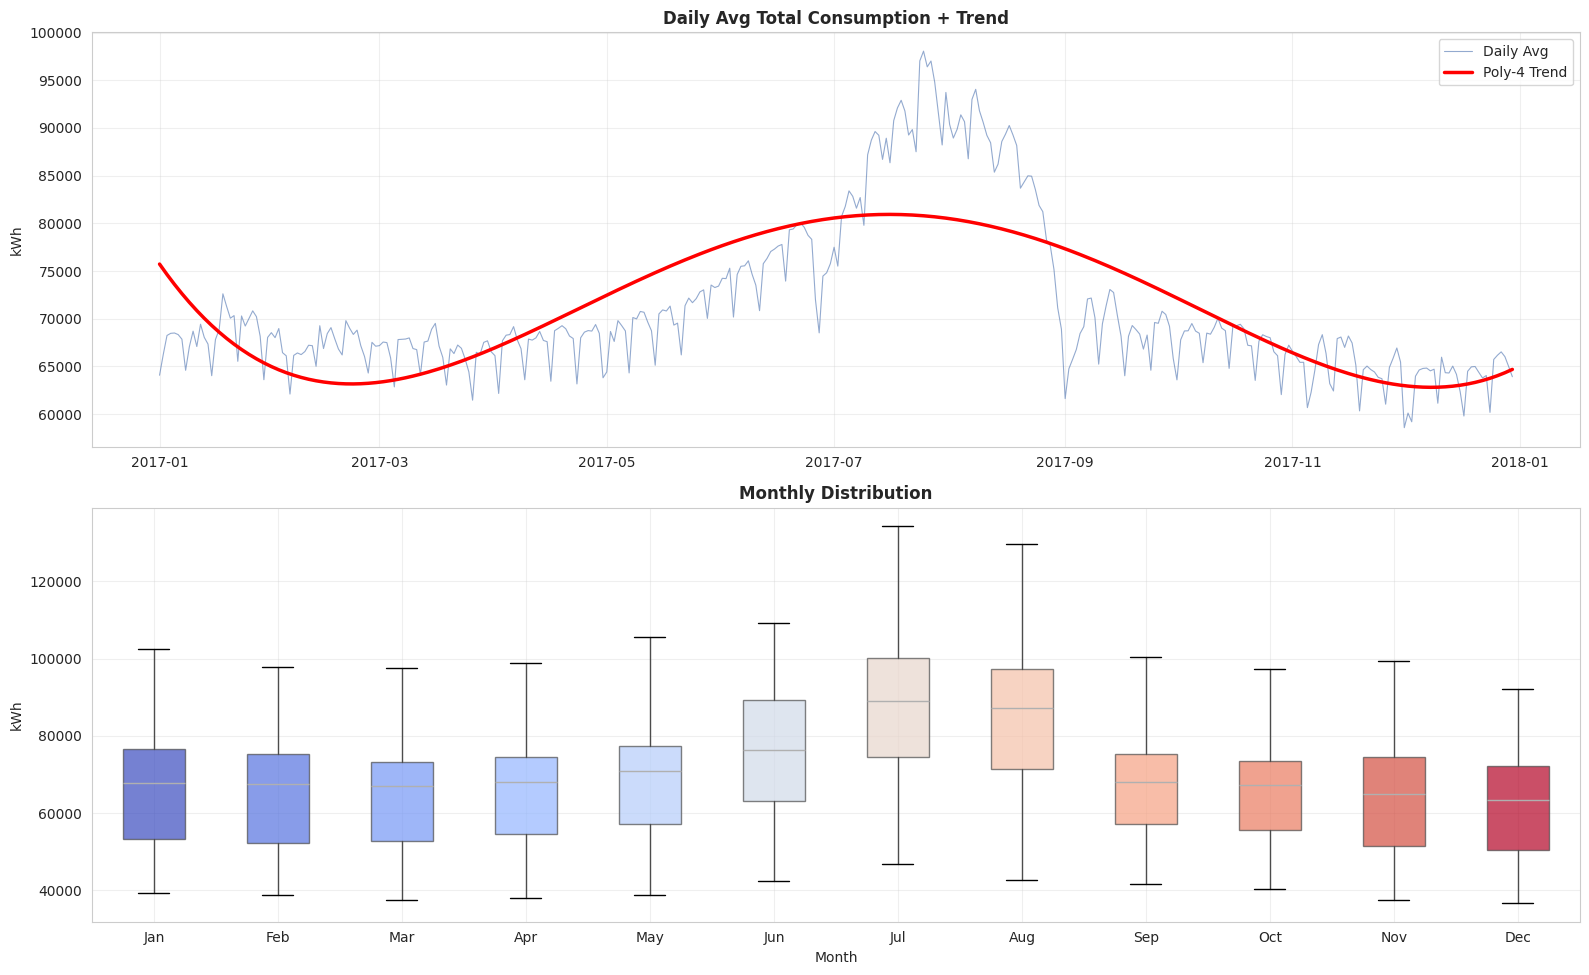

In [11]:
daily = df.resample('D').mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ax = axes[0]
ax.plot(daily.index, daily['TotalConsumption'], alpha=0.6, lw=0.8, label='Daily Avg')
x = np.arange(len(daily))
p = np.poly1d(np.polyfit(x, daily['TotalConsumption'].values, 4))
ax.plot(daily.index, p(x), color='red', lw=2.5, label='Poly-4 Trend')
ax.set_title('Daily Avg Total Consumption + Trend', fontweight='bold')
ax.set_ylabel('kWh'); ax.legend()

monthly = df.copy(); monthly['Month'] = monthly.index.month
mn = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax2 = axes[1]
bp = monthly.boxplot(column='TotalConsumption', by='Month', ax=ax2,
                      patch_artist=True, return_type='dict')
for patch, c in zip(bp['TotalConsumption']['boxes'],
                     plt.cm.coolwarm(np.linspace(0,1,12))):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax2.set_xticklabels(mn)
ax2.set_title('Monthly Distribution', fontweight='bold')
ax2.set_ylabel('kWh'); ax2.set_xlabel('Month')
fig.suptitle('')
plt.tight_layout(); plt.show()

**Interpretation:** Clear U-shaped seasonal pattern — spring trough (Mar-Apr), summer peak (Jul-Aug) from AC usage, minor winter rise from heating.

### Q2 — Weather Correlation

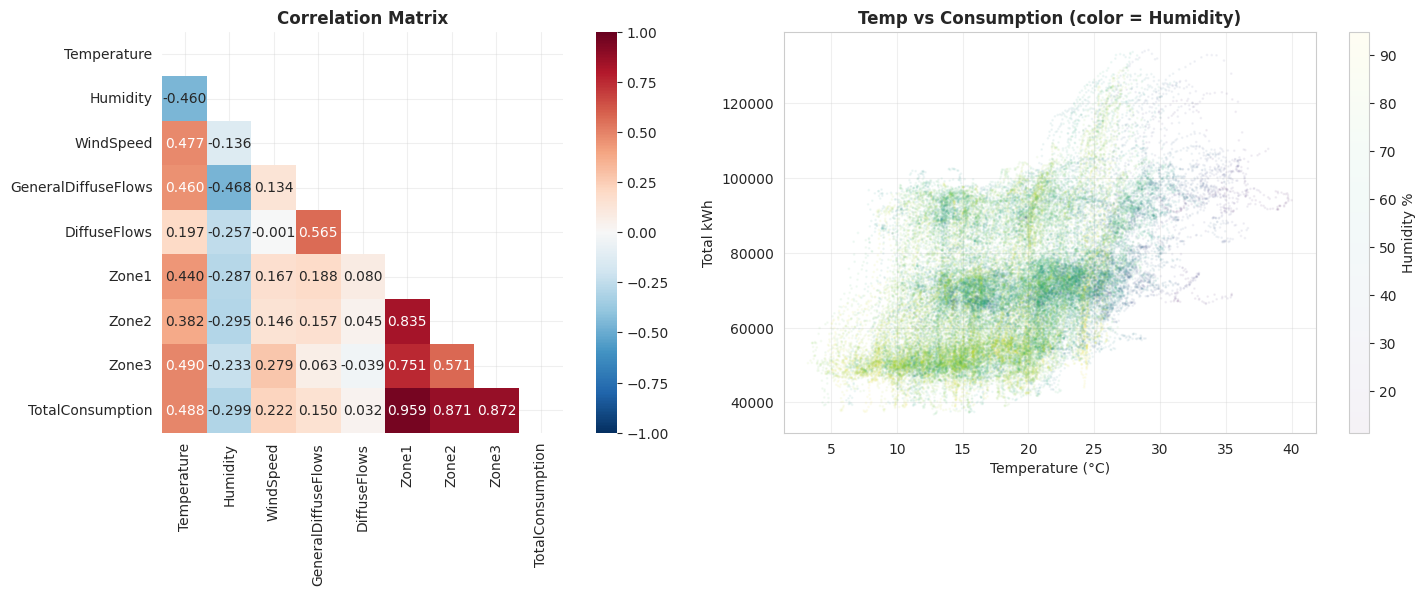

Correlations with TotalConsumption:
Zone1                  0.959146
Zone3                  0.871777
Zone2                  0.871069
Temperature            0.488238
WindSpeed              0.221706
GeneralDiffuseFlows    0.150368
DiffuseFlows           0.032068
Humidity              -0.299059
Name: TotalConsumption, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, ax=axes[0], square=True, vmin=-1, vmax=1)
axes[0].set_title('Correlation Matrix', fontweight='bold')

sc = axes[1].scatter(df['Temperature'], df['TotalConsumption'],
                     alpha=0.05, s=1, c=df['Humidity'], cmap='viridis')
axes[1].set_xlabel('Temperature (°C)'); axes[1].set_ylabel('Total kWh')
axes[1].set_title('Temp vs Consumption (color = Humidity)', fontweight='bold')
plt.colorbar(sc, ax=axes[1], label='Humidity %')
plt.tight_layout(); plt.show()

print("Correlations with TotalConsumption:")
print(corr['TotalConsumption'].drop('TotalConsumption').sort_values(ascending=False))

**Interpretation:** Temperature has moderate positive correlation (~0.44) — consumption rises sharply above 25 °C (nonlinear, AC-driven). Humidity is negatively correlated. The three zones correlate strongly with each other (>0.58).

### Q3 (Lagged Features) — Autocorrelation of Daily Consumption

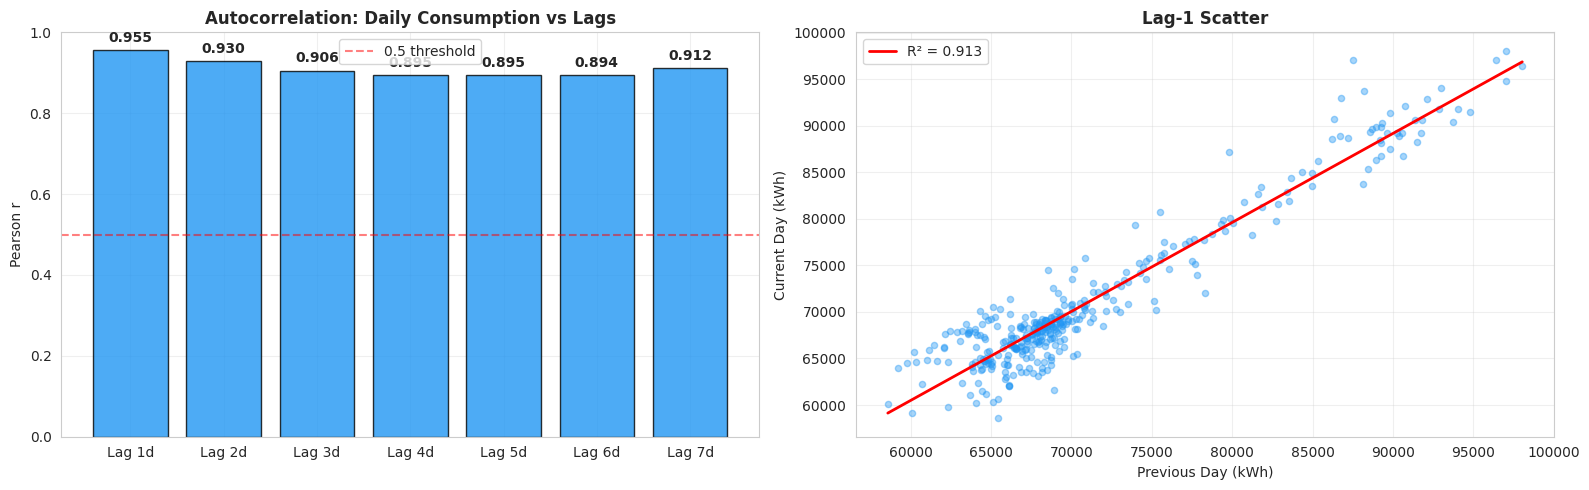

In [13]:
daily_tc = df['TotalConsumption'].resample('D').mean()
lag_corrs = {i: daily_tc.corr(daily_tc.shift(i)) for i in range(1, 8)}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

labels = ['Lag {}d'.format(i) for i in range(1, 8)]
vals = list(lag_corrs.values())
colors = ['#2196F3' if v > 0.5 else '#FF9800' if v > 0.3 else '#9E9E9E'
          for v in vals]
axes[0].bar(labels, vals, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylim(0, 1)
axes[0].set_title('Autocorrelation: Daily Consumption vs Lags', fontweight='bold')
axes[0].set_ylabel('Pearson r')
axes[0].axhline(0.5, color='red', ls='--', alpha=0.5, label='0.5 threshold')
axes[0].legend()
for i, v in enumerate(vals):
    axes[0].text(i, v+0.02, '{:.3f}'.format(v), ha='center', fontweight='bold')

axes[1].scatter(daily_tc.shift(1), daily_tc, alpha=0.4, s=20, color='#2196F3')
axes[1].set_xlabel('Previous Day (kWh)'); axes[1].set_ylabel('Current Day (kWh)')
axes[1].set_title('Lag-1 Scatter', fontweight='bold')
ok = ~(daily_tc.shift(1).isna() | daily_tc.isna())
sl, ic, r, _, _ = stats.linregress(daily_tc.shift(1)[ok], daily_tc[ok])
xr = np.linspace(daily_tc.min(), daily_tc.max(), 100)
axes[1].plot(xr, sl*xr+ic, color='red', lw=2, label='R² = {:.3f}'.format(r**2))
axes[1].legend()
plt.tight_layout(); plt.show()

**Interpretation:** Lag-1 has the strongest autocorrelation — weather patterns persist day-to-day. Correlations decay through lag-7, hinting at weekly cycles. Including lag features will boost forecasting accuracy.

### Q4 (Moving Averages) — Trend Decomposition via Rolling Windows

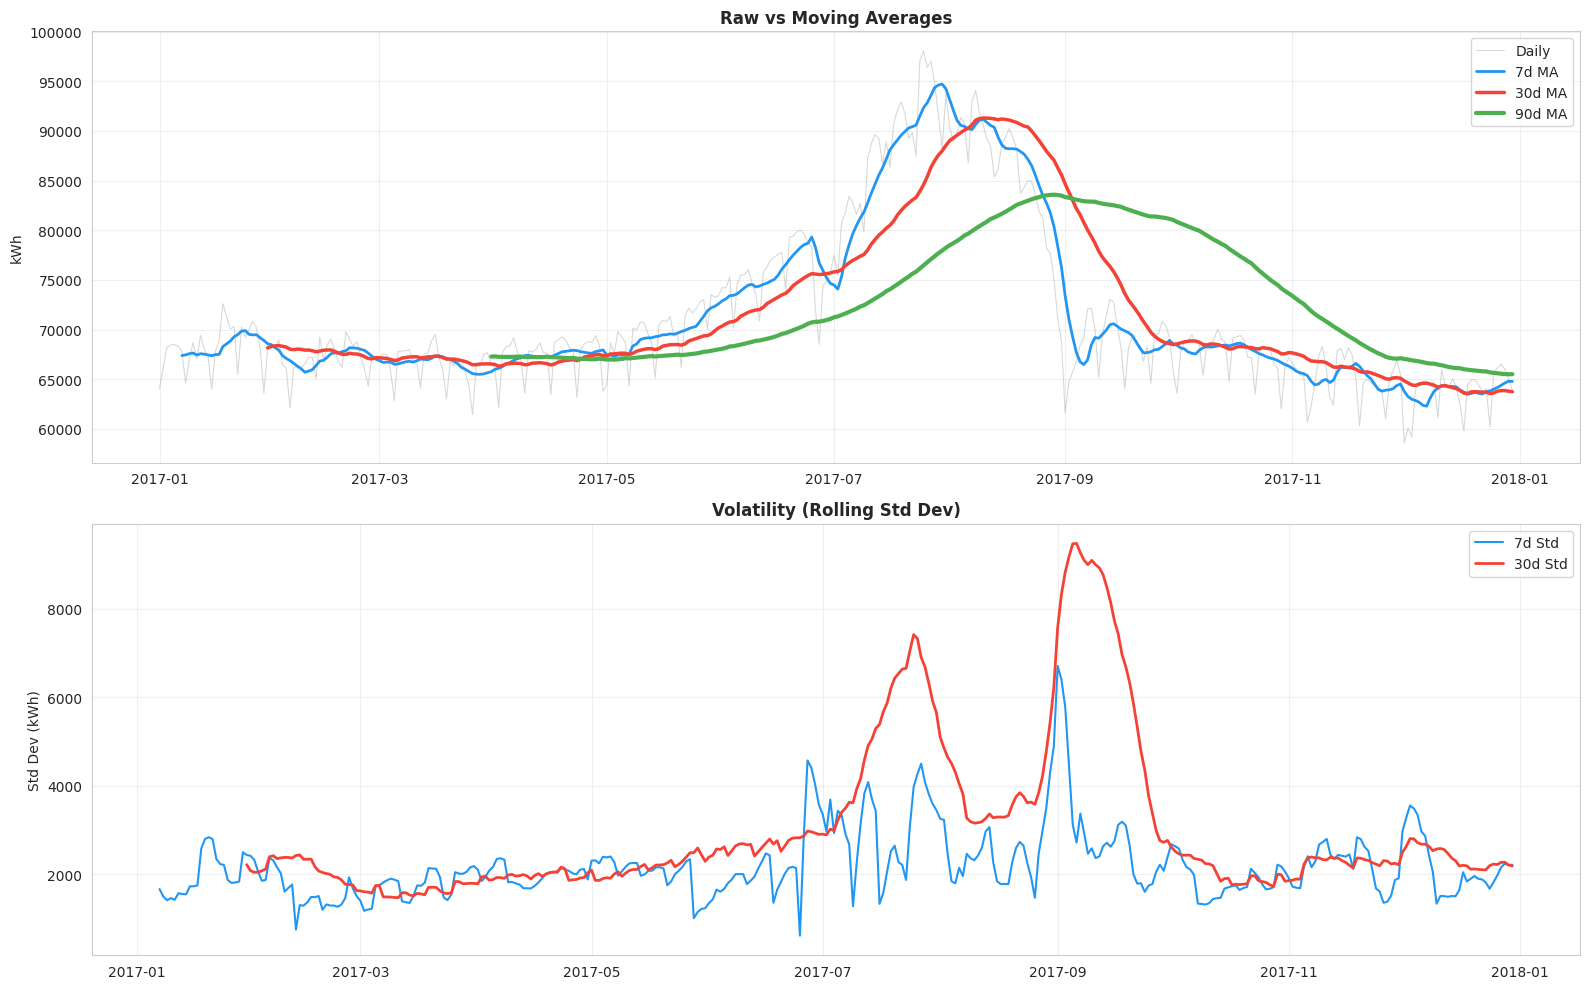

In [14]:
daily_tc = df['TotalConsumption'].resample('D').mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(daily_tc.index, daily_tc, alpha=0.3, lw=0.8, color='gray', label='Daily')
axes[0].plot(daily_tc.index, daily_tc.rolling(7).mean(), lw=2, color='#2196F3', label='7d MA')
axes[0].plot(daily_tc.index, daily_tc.rolling(30).mean(), lw=2.5, color='#F44336', label='30d MA')
axes[0].plot(daily_tc.index, daily_tc.rolling(90).mean(), lw=3, color='#4CAF50', label='90d MA')
axes[0].set_title('Raw vs Moving Averages', fontweight='bold')
axes[0].set_ylabel('kWh'); axes[0].legend()

axes[1].plot(daily_tc.index, daily_tc.rolling(7).std(), lw=1.5, color='#2196F3', label='7d Std')
axes[1].plot(daily_tc.index, daily_tc.rolling(30).std(), lw=2, color='#F44336', label='30d Std')
axes[1].set_title('Volatility (Rolling Std Dev)', fontweight='bold')
axes[1].set_ylabel('Std Dev (kWh)'); axes[1].legend()
plt.tight_layout(); plt.show()

**Interpretation:** The 30-day MA reveals the seasonal arc clearly — spring trough to summer peak (~40-50 % higher). Volatility spikes in summer from weather-sensitive AC loads. Both 7-day and 30-day MAs are valuable model features.

### Q5 — Hourly & Day-of-Week Patterns

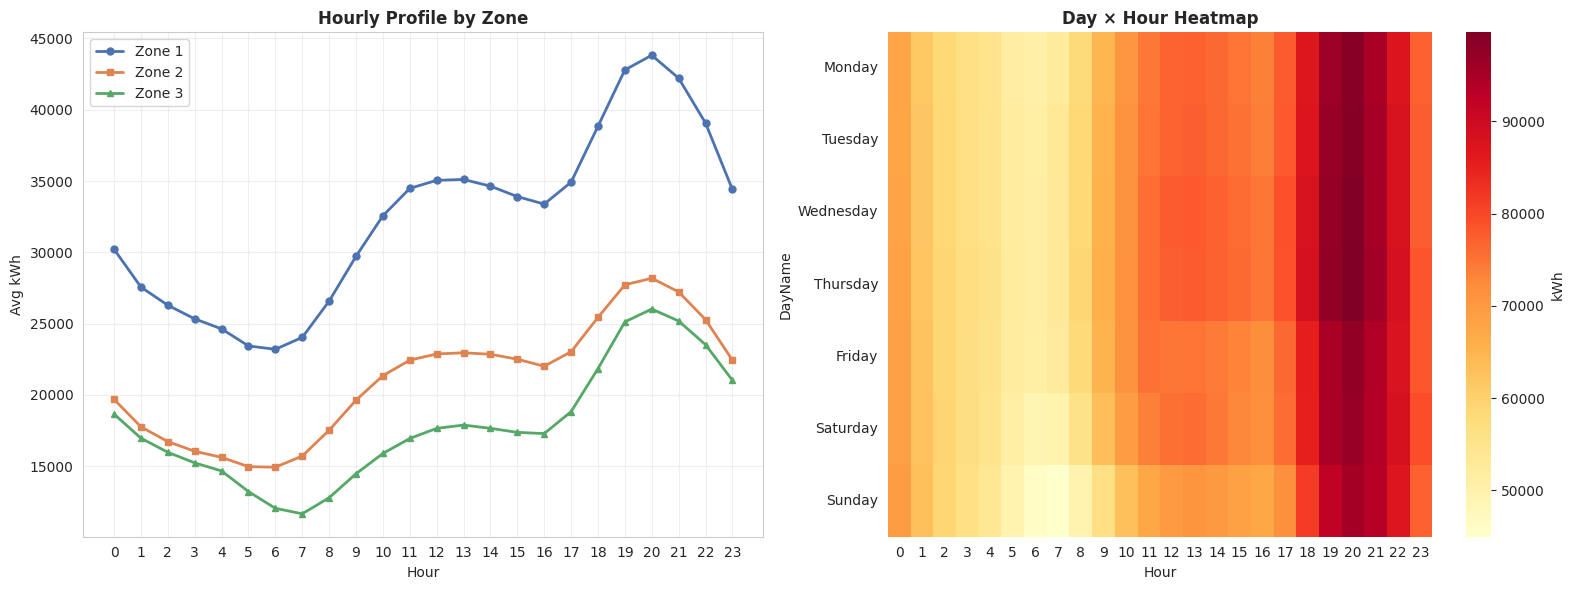

Peak hour:     20:00 — 98,037 kWh
Off-peak hour: 6:00 — 50,190 kWh
Ratio: 1.95x


In [15]:
tmp = df.copy()
tmp['Hour'] = tmp.index.hour
tmp['DayName'] = tmp.index.day_name()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ha = tmp.groupby('Hour')[['Zone1','Zone2','Zone3']].mean()
axes[0].plot(ha.index, ha['Zone1'], 'o-', label='Zone 1', lw=2, ms=5)
axes[0].plot(ha.index, ha['Zone2'], 's-', label='Zone 2', lw=2, ms=5)
axes[0].plot(ha.index, ha['Zone3'], '^-', label='Zone 3', lw=2, ms=5)
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Avg kWh')
axes[0].set_title('Hourly Profile by Zone', fontweight='bold')
axes[0].set_xticks(range(24)); axes[0].legend()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pv = tmp.groupby(['DayName','Hour'])['TotalConsumption'].mean().reset_index()
pt = pv.pivot(index='DayName', columns='Hour', values='TotalConsumption').reindex(day_order)
sns.heatmap(pt, cmap='YlOrRd', ax=axes[1], cbar_kws={'label':'kWh'})
axes[1].set_title('Day × Hour Heatmap', fontweight='bold')
plt.tight_layout(); plt.show()

th = ha.sum(axis=1)
print("Peak hour:     {}:00 — {:,.0f} kWh".format(th.idxmax(), th.max()))
print("Off-peak hour: {}:00 — {:,.0f} kWh".format(th.idxmin(), th.min()))
print("Ratio: {:.2f}x".format(th.max() / th.min()))

**Interpretation:** All zones peak around noon and dip at night. Weekday consumption exceeds weekends (commercial loads). Zone 1 carries ~50 % more than Zone 2.

> **Section lead:** Elvin Cyubahiro — feature engineering, model experiments, hyperparameter tuning, and experiment comparison (see commit history in the repository).


## Part C: Model Training

XGBoost vs Random Forest on hourly-resampled data with engineered features.

### C.1 Feature Engineering

In [16]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import joblib

hourly = df.resample('1h').mean()
feat = hourly.copy()

# Cyclical time
feat['Hour_sin']      = np.sin(2*np.pi*feat.index.hour/24)
feat['Hour_cos']      = np.cos(2*np.pi*feat.index.hour/24)
feat['Month_sin']     = np.sin(2*np.pi*feat.index.month/12)
feat['Month_cos']     = np.cos(2*np.pi*feat.index.month/12)
feat['DoW_sin']       = np.sin(2*np.pi*feat.index.dayofweek/7)
feat['DoW_cos']       = np.cos(2*np.pi*feat.index.dayofweek/7)
feat['IsWeekend']     = (feat.index.dayofweek >= 5).astype(int)

# Lags
for lag in [1,2,3,6,12,24,48,168]:
    feat['Lag_{}h'.format(lag)] = feat['TotalConsumption'].shift(lag)

# Rolling stats
for w in [6,12,24,48,168]:
    feat['MA_{}h'.format(w)]  = feat['TotalConsumption'].shift(1).rolling(w).mean()
    feat['Std_{}h'.format(w)] = feat['TotalConsumption'].shift(1).rolling(w).std()

# Interactions
feat['Temp_sq']       = feat['Temperature']**2
feat['Temp_x_Hum']    = feat['Temperature'] * feat['Humidity']

feat = feat.dropna()
print("Feature matrix:", feat.shape)

Feature matrix: (8568, 36)


### C.2 Train / Test Split

In [17]:
exclude = ['Zone1','Zone2','Zone3','TotalConsumption']
feature_cols = [c for c in feat.columns if c not in exclude]

X = feat[feature_cols]; y = feat['TotalConsumption']
split = int(len(X)*0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print("Train:", X_train.shape, " | ", X_train.index.min().date(), "->", X_train.index.max().date())
print("Test: ", X_test.shape, " | ", X_test.index.min().date(), "->", X_test.index.max().date())

Train: (6854, 32)  |  2017-01-08 -> 2017-10-20
Test:  (1714, 32)  |  2017-10-20 -> 2017-12-30


### C.3 Experiment 1 — XGBoost (3 configs)

In [18]:
tscv = TimeSeriesSplit(n_splits=3)

xgb_cfgs = {
    'XGB_v1': dict(n_estimators=200, max_depth=4, learning_rate=0.1,
                   subsample=0.8, colsample_bytree=0.8),
    'XGB_v2': dict(n_estimators=300, max_depth=6, learning_rate=0.1,
                   subsample=0.8, colsample_bytree=0.8),
    'XGB_v3': dict(n_estimators=500, max_depth=8, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8),
}

xgb_res = {}
for name, params in xgb_cfgs.items():
    m = XGBRegressor(**params, random_state=42, n_jobs=-1, verbosity=0)
    cv = []
    for ti, vi in tscv.split(X_train):
        m.fit(X_train.iloc[ti], y_train.iloc[ti])
        cv.append(mean_absolute_error(y_train.iloc[vi], m.predict(X_train.iloc[vi])))
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    xgb_res[name] = dict(model=m, pred=p, params=params,
        cv_mae=np.mean(cv),
        rmse=np.sqrt(mean_squared_error(y_test, p)),
        mae=mean_absolute_error(y_test, p),
        r2=r2_score(y_test, p))
    print("{}: CV MAE={:,.0f}  Test RMSE={:,.0f}  R2={:.4f}".format(
        name, xgb_res[name]['cv_mae'], xgb_res[name]['rmse'], xgb_res[name]['r2']))

best_xgb = min(xgb_res.values(), key=lambda x: x['mae'])

XGB_v1: CV MAE=2,466  Test RMSE=1,835  R2=0.9828
XGB_v2: CV MAE=2,477  Test RMSE=1,796  R2=0.9836
XGB_v3: CV MAE=2,524  Test RMSE=1,839  R2=0.9828


### C.4 Experiment 2 — Random Forest (3 configs)

In [19]:
rf_cfgs = {
    'RF_v1': dict(n_estimators=200, max_depth=10, min_samples_split=5, min_samples_leaf=2),
    'RF_v2': dict(n_estimators=300, max_depth=15, min_samples_split=5, min_samples_leaf=2),
    'RF_v3': dict(n_estimators=500, max_depth=20, min_samples_split=10,min_samples_leaf=4),
}

rf_res = {}
for name, params in rf_cfgs.items():
    m = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    cv = []
    for ti, vi in tscv.split(X_train):
        m.fit(X_train.iloc[ti], y_train.iloc[ti])
        cv.append(mean_absolute_error(y_train.iloc[vi], m.predict(X_train.iloc[vi])))
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    rf_res[name] = dict(model=m, pred=p, params=params,
        cv_mae=np.mean(cv),
        rmse=np.sqrt(mean_squared_error(y_test, p)),
        mae=mean_absolute_error(y_test, p),
        r2=r2_score(y_test, p))
    print("{}: CV MAE={:,.0f}  Test RMSE={:,.0f}  R2={:.4f}".format(
        name, rf_res[name]['cv_mae'], rf_res[name]['rmse'], rf_res[name]['r2']))

best_rf = min(rf_res.values(), key=lambda x: x['mae'])

RF_v1: CV MAE=2,506  Test RMSE=2,112  R2=0.9773
RF_v2: CV MAE=2,478  Test RMSE=2,054  R2=0.9785
RF_v3: CV MAE=2,475  Test RMSE=2,061  R2=0.9784


### C.5 Experiment Comparison Table

In [20]:
rows = []
for name, r in {**xgb_res, **rf_res}.items():
    rows.append(dict(Config=name,
        CV_MAE="{:,.0f}".format(r['cv_mae']),
        Test_RMSE="{:,.0f}".format(r['rmse']),
        Test_MAE="{:,.0f}".format(r['mae']),
        Test_R2="{:.4f}".format(r['r2'])))
table = pd.DataFrame(rows)
print("=" * 75)
print("EXPERIMENT COMPARISON")
print("=" * 75)
print(table.to_string(index=False))
print("=" * 75)

if best_xgb['r2'] >= best_rf['r2']:
    best_name = 'XGBoost'; best_model = best_xgb['model']; best_pred = best_xgb['pred']
else:
    best_name = 'Random Forest'; best_model = best_rf['model']; best_pred = best_rf['pred']
print()
print("Best model:", best_name, "  R2 =", "{:.4f}".format(max(best_xgb['r2'], best_rf['r2'])))

EXPERIMENT COMPARISON
Config CV_MAE Test_RMSE Test_MAE Test_R2
XGB_v1  2,466     1,835    1,339  0.9828
XGB_v2  2,477     1,796    1,294  0.9836
XGB_v3  2,524     1,839    1,322  0.9828
 RF_v1  2,506     2,112    1,469  0.9773
 RF_v2  2,478     2,054    1,416  0.9785
 RF_v3  2,475     2,061    1,415  0.9784

Best model: XGBoost   R2 = 0.9836


### C.6 Prediction Visualization

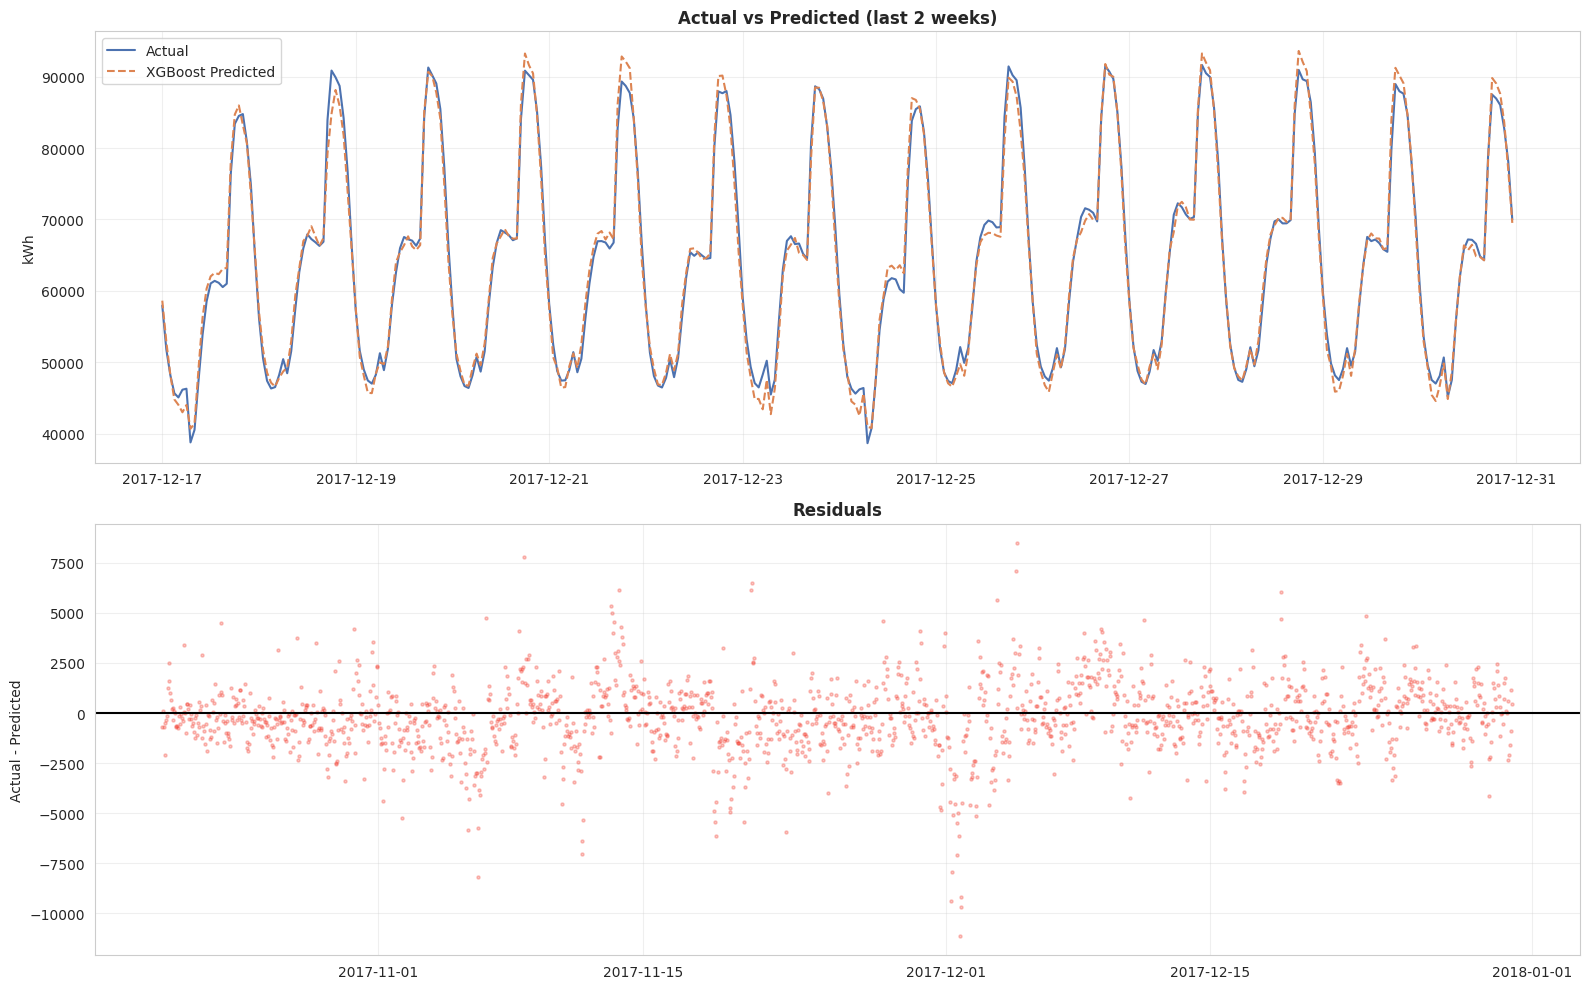

Residual mean: -208.8   std: 1783.7


In [21]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

n = 24*14
axes[0].plot(y_test.index[-n:], y_test.values[-n:], label='Actual', lw=1.5)
axes[0].plot(y_test.index[-n:], best_pred[-n:], label=best_name+' Predicted', lw=1.5, ls='--')
axes[0].set_title('Actual vs Predicted (last 2 weeks)', fontweight='bold')
axes[0].set_ylabel('kWh'); axes[0].legend()

resid = y_test.values - best_pred
axes[1].scatter(y_test.index, resid, alpha=0.3, s=5, color='#F44336')
axes[1].axhline(0, color='black', lw=1.5)
axes[1].set_title('Residuals', fontweight='bold'); axes[1].set_ylabel('Actual - Predicted')
plt.tight_layout(); plt.show()
print("Residual mean: {:.1f}   std: {:.1f}".format(resid.mean(), resid.std()))

### C.7 Feature Importance

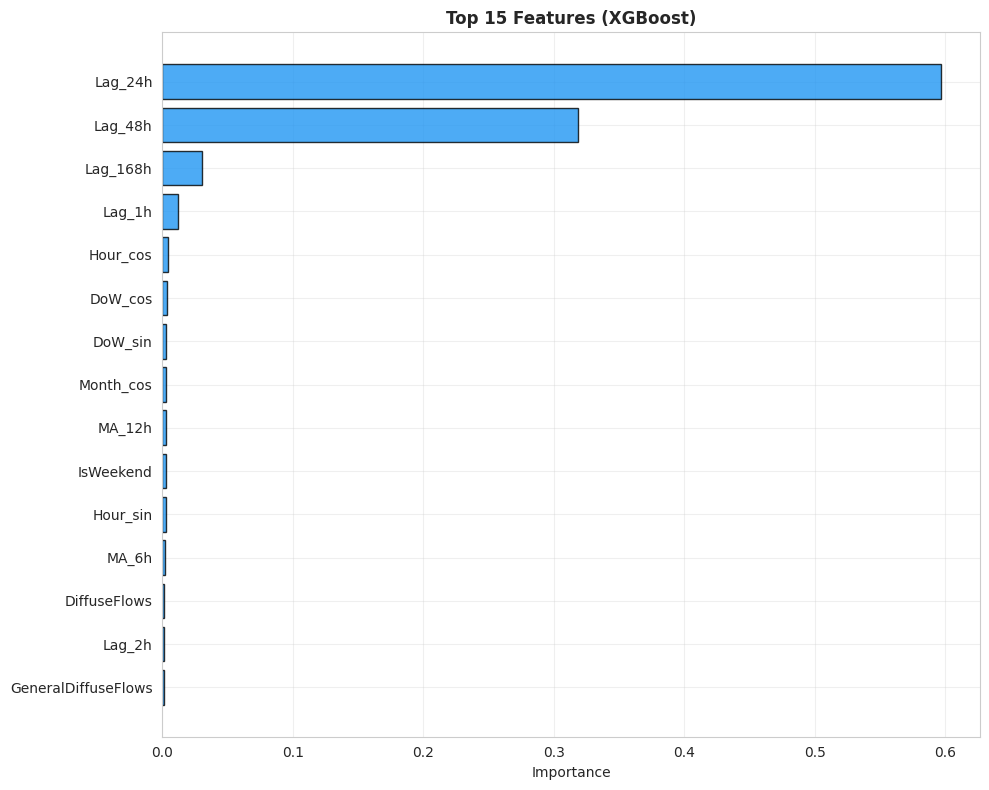

In [22]:
imp = pd.DataFrame({'Feature': feature_cols,
                     'Importance': best_model.feature_importances_})
imp = imp.sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(imp['Feature'], imp['Importance'], color='#2196F3', edgecolor='black', alpha=0.8)
ax.set_title('Top 15 Features ({})'.format(best_name), fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

**Interpretation:** Lag features (especially lag-1h, lag-24h) and rolling averages dominate, confirming recent history is the strongest predictor. Weather adds secondary value.

### C.8 Save Model

In [23]:
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')
print("Saved best_model.pkl and feature_cols.pkl")

Saved best_model.pkl and feature_cols.pkl


---
# Task 2: Database Design (SQL & MongoDB)

We use **MySQL** (via [FreeSQLDatabase.com](https://freesqldatabase.com) free-tier) and **MongoDB** (via [MongoDB Atlas](https://www.mongodb.com/atlas) free-tier M0 cluster).

> **Setup instructions** are provided in the README. Connection credentials are configured at the top of this section.

> **Section lead:** Heroine Mutumwinka — Task 2. MySQL schema (3 tables + ERD + indexes), data seeding, 3 SQL queries; MongoDB collection design, document insertion, 3 aggregation queries (see commit history in the repository).

### Entity Relationship Diagram (ERD)

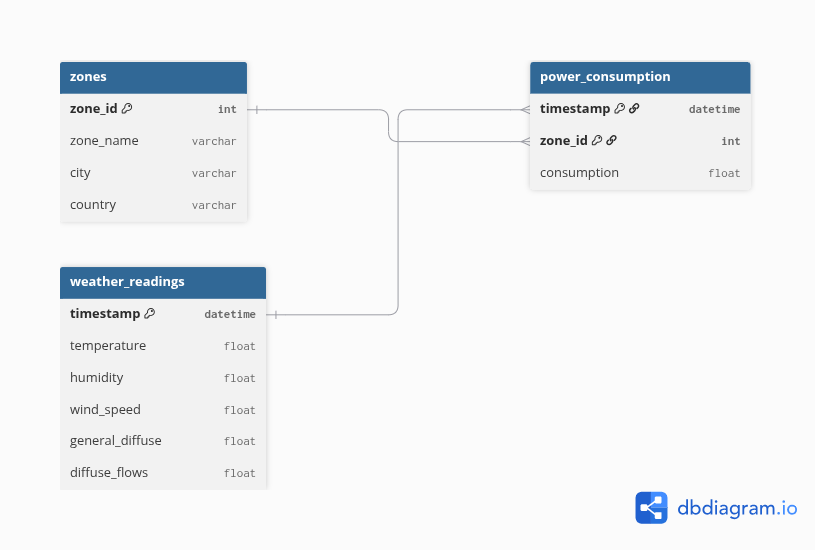


### MySQL Connection Setup

**Credentials are loaded from Colab's Secrets manager — never hardcoded.** This keeps them out of the notebook file itself, so it's safe to push to GitHub.

**One-time setup in Colab:**
1. Click the key icon (🔑) in the left sidebar → "Secrets"
2. Add 4 secrets: `MYSQL_HOST`, `MYSQL_USER`, `MYSQL_PASSWORD`, `MYSQL_DATABASE`
3. Toggle "Notebook access" on for each
4. Run the cell below — it reads them automatically, nothing to edit

In [24]:
!pip install -q mysql-connector-python

import mysql.connector
import os

try:
    from google.colab import userdata
    MYSQL_CONFIG = {
        'host':     userdata.get('MYSQL_HOST'),
        'user':     userdata.get('MYSQL_USER'),
        'password': userdata.get('MYSQL_PASSWORD'),
        'database': userdata.get('MYSQL_DATABASE'),
    }
except ImportError:
    # Fallback for non-Colab environments (e.g. local Jupyter): use env vars
    MYSQL_CONFIG = {
        'host':     os.environ['MYSQL_HOST'],
        'user':     os.environ['MYSQL_USER'],
        'password': os.environ['MYSQL_PASSWORD'],
        'database': os.environ['MYSQL_DATABASE'],
    }

conn = mysql.connector.connect(**MYSQL_CONFIG)
cur = conn.cursor()
print("Connected to MySQL:", MYSQL_CONFIG['host'])

Connected to MySQL: sql7.freesqldatabase.com


### Schema Scripts

In [25]:
# Drop existing tables (order matters due to foreign keys)
cur.execute('DROP TABLE IF EXISTS power_consumption')
cur.execute('DROP TABLE IF EXISTS weather_readings')
cur.execute('DROP TABLE IF EXISTS zones')

# Table 1: zones (dimension table)
cur.execute('''
    CREATE TABLE zones (
        zone_id      INT PRIMARY KEY,
        zone_name    VARCHAR(50) NOT NULL,
        station      VARCHAR(100) NOT NULL,
        description  TEXT
    )
''')

# Table 2: weather_readings (fact table)
cur.execute('''
    CREATE TABLE weather_readings (
        reading_id       INT AUTO_INCREMENT PRIMARY KEY,
        timestamp        DATETIME NOT NULL,
        temperature      FLOAT NOT NULL,
        humidity         FLOAT NOT NULL,
        wind_speed       FLOAT NOT NULL,
        general_diffuse  FLOAT NOT NULL,
        diffuse_flows    FLOAT NOT NULL,
        INDEX idx_w_ts (timestamp)
    )
''')

# Table 3: power_consumption (fact table)
cur.execute('''
    CREATE TABLE power_consumption (
        consumption_id  INT AUTO_INCREMENT PRIMARY KEY,
        zone_id         INT NOT NULL,
        timestamp       DATETIME NOT NULL,
        consumption     FLOAT NOT NULL,
        FOREIGN KEY (zone_id) REFERENCES zones(zone_id),
        INDEX idx_c_ts (timestamp),
        INDEX idx_c_zone (zone_id)
    )
''')

conn.commit()
print("MySQL schema created (3 tables + indexes).")

MySQL schema created (3 tables + indexes).


### Seed Data

In [26]:
# Insert zone metadata
cur.executemany(
    'INSERT INTO zones (zone_id, zone_name, station, description) VALUES (%s,%s,%s,%s)',
    [
        (1, 'Zone 1', 'Quads',     'Northern — highest consumption, commercial district'),
        (2, 'Zone 2', 'Smir',      'Central — mixed residential/commercial'),
        (3, 'Zone 3', 'Boussafou', 'Southern — primarily residential'),
    ]
)

# Resample to hourly for manageable DB size
h = df.resample('1h').mean().reset_index()

# Insert weather readings
w_rows = [(r.DateTime.strftime('%Y-%m-%d %H:%M:%S'),
           round(r.Temperature,3), round(r.Humidity,3),
           round(r.WindSpeed,3), round(r.GeneralDiffuseFlows,3),
           round(r.DiffuseFlows,3)) for r in h.itertuples()]
cur.executemany(
    'INSERT INTO weather_readings (timestamp,temperature,humidity,'
    'wind_speed,general_diffuse,diffuse_flows) VALUES (%s,%s,%s,%s,%s,%s)', w_rows)

# Insert consumption (3 rows per timestamp — one per zone)
c_rows = []
for r in h.itertuples():
    ts = r.DateTime.strftime('%Y-%m-%d %H:%M:%S')
    c_rows.append((1, ts, round(r.Zone1, 3)))
    c_rows.append((2, ts, round(r.Zone2, 3)))
    c_rows.append((3, ts, round(r.Zone3, 3)))
cur.executemany(
    'INSERT INTO power_consumption (zone_id,timestamp,consumption) VALUES (%s,%s,%s)', c_rows)

conn.commit()
print("Seeded {} weather readings, {} consumption records.".format(len(w_rows), len(c_rows)))

Seeded 8736 weather readings, 26208 consumption records.


### SQL Queries

In [27]:
print("QUERY 1: Average consumption per zone")
print("-" * 60)
cur.execute('''
    SELECT z.zone_name, z.station,
           ROUND(AVG(pc.consumption),2) AS avg_c,
           ROUND(MIN(pc.consumption),2) AS min_c,
           ROUND(MAX(pc.consumption),2) AS max_c
    FROM power_consumption pc
    JOIN zones z ON pc.zone_id = z.zone_id
    GROUP BY z.zone_id ORDER BY avg_c DESC
''')
for row in cur.fetchall():
    print("  {} ({}):  avg={:>10}  min={:>10}  max={:>10}".format(*row))

QUERY 1: Average consumption per zone
------------------------------------------------------------
  Zone 1 (Quads):  avg=  32344.97  min=  14329.11  max=  51844.26
  Zone 2 (Smir):  avg=  21042.51  min=   8685.95  max=   36254.7
  Zone 3 (Boussafou):  avg=  17835.41  min=   6190.64  max=  47223.77


In [28]:
print("QUERY 2: Top 10 hottest hours + total consumption")
print("-" * 60)
cur.execute('''
    SELECT w.timestamp, w.temperature,
           ROUND(SUM(pc.consumption),2) AS total
    FROM weather_readings w
    JOIN power_consumption pc ON w.timestamp = pc.timestamp
    GROUP BY w.timestamp ORDER BY w.temperature DESC LIMIT 10
''')
for row in cur.fetchall():
    print("  {}  {:.1f} C  {:>12} kWh".format(row[0], row[1], row[2]))

QUERY 2: Top 10 hottest hours + total consumption
------------------------------------------------------------
  2017-07-21 14:00:00  39.7 C      95138.99 kWh
  2017-07-21 15:00:00  39.7 C       93419.8 kWh
  2017-07-21 16:00:00  39.1 C      92334.75 kWh
  2017-07-21 13:00:00  39.0 C      95885.38 kWh
  2017-07-21 17:00:00  38.7 C      91655.02 kWh
  2017-07-21 12:00:00  37.8 C      95711.91 kWh
  2017-07-21 18:00:00  37.6 C      93320.26 kWh
  2017-07-27 12:00:00  37.2 C     107053.04 kWh
  2017-07-10 15:00:00  36.9 C      93847.66 kWh
  2017-07-18 16:00:00  36.6 C      96573.25 kWh


In [29]:
print("QUERY 3: Monthly avg consumption by zone")
print("-" * 60)
month_names = 'Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec'.split()
cur.execute('''
    SELECT MONTH(pc.timestamp) AS m, z.zone_name,
           ROUND(AVG(pc.consumption),2) AS avg_c
    FROM power_consumption pc
    JOIN zones z ON pc.zone_id = z.zone_id
    GROUP BY m, z.zone_name ORDER BY m, z.zone_name
''')
for row in cur.fetchall():
    print("  {} {:<8} {:>10}".format(month_names[row[0]-1], row[1], row[2]))

QUERY 3: Monthly avg consumption by zone
------------------------------------------------------------
  Jan Zone 1     31032.49
  Jan Zone 2     19394.44
  Jan Zone 3      17746.1
  Feb Zone 1     30985.75
  Feb Zone 2     18787.79
  Feb Zone 3      17335.0
  Mar Zone 1     31155.17
  Mar Zone 2     18457.94
  Mar Zone 3     16947.69
  Apr Zone 1     31169.77
  Apr Zone 2     17633.97
  Apr Zone 3     18593.17
  May Zone 1     32396.01
  May Zone 2     19977.29
  May Zone 3      17621.1
  Jun Zone 1     34605.54
  Jun Zone 2     20670.93
  Jun Zone 3     20430.94
  Jul Zone 1     35831.55
  Jul Zone 2     24147.89
  Jul Zone 3     28194.11
  Aug Zone 1     36435.19
  Aug Zone 2     24656.22
  Aug Zone 3     24648.89
  Sep Zone 1     33396.68
  Sep Zone 2     20180.43
  Sep Zone 3      14922.8
  Oct Zone 1     32827.66
  Oct Zone 2     21468.99
  Oct Zone 3      13264.1
  Nov Zone 1     29002.11
  Nov Zone 2     23240.46
  Nov Zone 3      12862.5
  Dec Zone 1     29024.17
  Dec Zone 2  

## 2.2 MongoDB Collection (MongoDB Atlas)

Using **MongoDB Atlas** free-tier (M0 cluster). The document schema is denormalized — each document is one hourly reading with weather and zone consumption nested.

**Credentials are loaded from Colab's Secrets manager** (same approach as MySQL above).

**One-time setup in Colab:**
1. Key icon (🔑) in the left sidebar → "Secrets"
2. Add a secret named `MONGO_URI` with your full Atlas connection string as the value
3. Toggle "Notebook access" on

### MongoDB Connection & Document Insertion

In [30]:
!pip install -q pymongo

from pymongo import MongoClient
import json, os

try:
    from google.colab import userdata
    MONGO_URI = userdata.get('MONGO_URI')
except ImportError:
    MONGO_URI = os.environ['MONGO_URI']

mongo_client = MongoClient(MONGO_URI)
mdb = mongo_client['tetouan_power']
coll = mdb['readings']

# Clear existing data
coll.drop()

# Insert documents
h = df.resample('1h').mean().reset_index()
docs = []
for r in h.itertuples():
    docs.append({
        'timestamp': r.DateTime.isoformat(),
        'weather': {
            'temperature': round(r.Temperature,3),
            'humidity': round(r.Humidity,3),
            'wind_speed': round(r.WindSpeed,3),
            'general_diffuse': round(r.GeneralDiffuseFlows,3),
            'diffuse_flows': round(r.DiffuseFlows,3),
        },
        'consumption': {
            'zone1': round(r.Zone1,3),
            'zone2': round(r.Zone2,3),
            'zone3': round(r.Zone3,3),
            'total': round(r.Zone1+r.Zone2+r.Zone3,3),
        },
        'metadata': {'city':'Tetouan','country':'Morocco','freq':'hourly'},
    })
coll.insert_many(docs)
print("Inserted {} documents into MongoDB Atlas.".format(len(docs)))

Inserted 8736 documents into MongoDB Atlas.


### Sample Document

In [31]:
sample = coll.find_one({}, {'_id': 0})
print(json.dumps(sample, indent=2, default=str))

{
  "timestamp": "2017-01-01T00:00:00",
  "weather": {
    "temperature": 6.197,
    "humidity": 75.067,
    "wind_speed": 0.082,
    "general_diffuse": 0.064,
    "diffuse_flows": 0.099
  },
  "consumption": {
    "zone1": 29197.975,
    "zone2": 18026.748,
    "zone3": 19252.048,
    "total": 66476.771
  },
  "metadata": {
    "city": "Tetouan",
    "country": "Morocco",
    "freq": "hourly"
  }
}


### MongoDB Queries

In [32]:
print("MONGO Q1: Summer averages (Jun-Aug)")
pipeline = [
    {'$match': {'timestamp': {'$gte': '2017-06-01', '$lt': '2017-09-01'}}},
    {'$group': {'_id': None,
                'avg_temp': {'$avg': '$weather.temperature'},
                'avg_total': {'$avg': '$consumption.total'},
                'count': {'$sum': 1}}}
]
for r in coll.aggregate(pipeline):
    print("  {} records | Avg temp: {:.1f} C | Avg total: {:,.0f} kWh".format(
        r['count'], r['avg_temp'], r['avg_total']))

MONGO Q1: Summer averages (Jun-Aug)
  2208 records | Avg temp: 25.1 C | Avg total: 83,289 kWh


In [33]:
print("MONGO Q2: Top 5 peak consumption")
for r in coll.find({}, {'_id':0,'timestamp':1,'consumption.total':1,'weather.temperature':1}
                  ).sort('consumption.total', -1).limit(5):
    print("  {} | {:>10,.0f} kWh | {:.1f} C".format(
        r['timestamp'], r['consumption']['total'], r['weather']['temperature']))

MONGO Q2: Top 5 peak consumption
  2017-07-24T20:00:00 |    133,130 kWh | 28.8 C
  2017-07-27T20:00:00 |    132,694 kWh | 27.8 C
  2017-07-25T20:00:00 |    132,330 kWh | 26.9 C
  2017-07-26T20:00:00 |    132,071 kWh | 33.3 C
  2017-07-24T21:00:00 |    129,515 kWh | 27.5 C


In [34]:
print("MONGO Q3: 24-hour consumption profile")
all_d = list(coll.find({}, {'_id':0,'timestamp':1,'consumption.total':1}))
ddf = pd.DataFrame(all_d)
ddf['hour'] = pd.to_datetime(ddf['timestamp']).dt.hour
ddf['total'] = ddf['consumption'].apply(lambda x: x['total'])
profile = ddf.groupby('hour')['total'].mean()
for h, v in profile.items():
    bar = '#' * int(v / 3000)
    print("  {:02d}:00  {:>10,.0f} kWh  {}".format(h, v, bar))

MONGO Q3: 24-hour consumption profile
  00:00      68,567 kWh  ######################
  01:00      62,301 kWh  ####################
  02:00      59,004 kWh  ###################
  03:00      56,629 kWh  ##################
  04:00      54,929 kWh  ##################
  05:00      51,639 kWh  #################
  06:00      50,190 kWh  ################
  07:00      51,425 kWh  #################
  08:00      56,907 kWh  ##################
  09:00      63,844 kWh  #####################
  10:00      69,823 kWh  #######################
  11:00      73,880 kWh  ########################
  12:00      75,588 kWh  #########################
  13:00      75,961 kWh  #########################
  14:00      75,159 kWh  #########################
  15:00      73,799 kWh  ########################
  16:00      72,691 kWh  ########################
  17:00      76,790 kWh  #########################
  18:00      86,141 kWh  ############################
  19:00      95,645 kWh  ###############################
  

---
# Task 3: CRUD Endpoints for Time-Series Queries

Flask REST API with full CRUD for both SQL and MongoDB backends, plus **latest record** and **date range** query endpoints.

> **Section lead:** Samuel Rurangamirwa — Tasks 3 & 4. Flask REST API (12 CRUD + time-series endpoints for MySQL and MongoDB), endpoint validation, and predict.py end-to-end forecast script (see commit history in the repository).

### 3.1 Write API (app.py)

`app.py` reads its database credentials from **environment variables**, not hardcoded values — this file is safe to commit to GitHub as-is, since it contains no secrets. The notebook passes the credentials it already loaded from Colab Secrets into the environment before starting the server.

In [35]:
APP_CODE = r'''
from flask import Flask, request, jsonify
import mysql.connector
from pymongo import MongoClient
import json, os

app = Flask(__name__)

# Credentials come from environment variables — never hardcoded.
MYSQL_CONFIG = {
    "host":     os.environ["MYSQL_HOST"],
    "user":     os.environ["MYSQL_USER"],
    "password": os.environ["MYSQL_PASSWORD"],
    "database": os.environ["MYSQL_DATABASE"],
    "connection_timeout": 10  # Added timeout to prevent hanging
}
MONGO_URI = os.environ["MONGO_URI"]

def get_db():
    return mysql.connector.connect(**MYSQL_CONFIG)

# Added serverSelectionTimeoutMS to prevent long hangs on startup
mongo_client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=10000)
mongo_coll = mongo_client["tetouan_power"]["readings"]

# ---- MySQL CRUD ----
@app.route("/api/sql/readings", methods=["POST"])
def sql_create():
    d = request.json; conn = get_db(); c = conn.cursor()
    c.execute("INSERT INTO weather_readings (timestamp,temperature,humidity,wind_speed,general_diffuse,diffuse_flows) VALUES (%s,%s,%s,%s,%s,%s)",
              (d["timestamp"],d["temperature"],d["humidity"],d["wind_speed"],d.get("general_diffuse",0),d.get("diffuse_flows",0)))
    for z in [1,2,3]:
        c.execute("INSERT INTO power_consumption (zone_id,timestamp,consumption) VALUES (%s,%s,%s)",
                  (z, d["timestamp"], d.get("zone{}".format(z), 0)))
    conn.commit(); conn.close()
    return jsonify({"message":"created","timestamp":d["timestamp"]}), 201

@app.route("/api/sql/readings/<path:ts>", methods=["GET"])
def sql_read(ts):
    conn = get_db(); c = conn.cursor(dictionary=True)
    c.execute("SELECT * FROM weather_readings WHERE timestamp=%s", (ts,))
    w = c.fetchone()
    if not w: conn.close(); return jsonify({"error":"not found"}), 404
    c.execute("SELECT zone_id,consumption FROM power_consumption WHERE timestamp=%s", (ts,))
    zones = c.fetchall(); conn.close()
    return jsonify({"timestamp":str(w["timestamp"]),"temperature":w["temperature"],
                    "humidity":w["humidity"],"wind_speed":w["wind_speed"],
                    "general_diffuse":w["general_diffuse"],"diffuse_flows":w["diffuse_flows"],
                    "zones":{"zone{}".format(r["zone_id"]):r["consumption"] for r in zones}})

@app.route("/api/sql/readings/<path:ts>", methods=["PUT"])
def sql_update(ts):
    d = request.json; conn = get_db(); c = conn.cursor()
    c.execute("UPDATE weather_readings SET temperature=%s, humidity=%s, wind_speed=%s WHERE timestamp=%s",
              (d.get("temperature"), d.get("humidity"), d.get("wind_speed"), ts))
    conn.commit(); conn.close()
    return jsonify({"message":"updated","timestamp":ts})

@app.route("/api/sql/readings/<path:ts>", methods=["DELETE"])
def sql_delete(ts):
    conn = get_db(); c = conn.cursor()
    c.execute("DELETE FROM weather_readings WHERE timestamp=%s", (ts,))
    c.execute("DELETE FROM power_consumption WHERE timestamp=%s", (ts,))
    conn.commit(); conn.close()
    return jsonify({"message":"deleted","timestamp":ts})

@app.route("/api/sql/readings/latest", methods=["GET"])
def sql_latest():
    try:
        conn = get_db(); c = conn.cursor(dictionary=True)
        c.execute("SELECT * FROM weather_readings ORDER BY timestamp DESC LIMIT 1")
        w = c.fetchone()
        if not w: conn.close(); return jsonify({"error":"empty"}), 404
        c.execute("SELECT zone_id,consumption FROM power_consumption WHERE timestamp=%s", (w["timestamp"],))
        zones = c.fetchall(); conn.close()
        return jsonify({"timestamp":str(w["timestamp"]),"temperature":w["temperature"],
                        "humidity":w["humidity"],"wind_speed":w["wind_speed"],
                        "general_diffuse":w["general_diffuse"],"diffuse_flows":w["diffuse_flows"],
                        "zones":{"zone{}".format(r["zone_id"]):r["consumption"] for r in zones}})
    except Exception as e:
        return jsonify({"error": str(e)}), 500

@app.route("/api/sql/readings/range", methods=["GET"])
def sql_range():
    s, e = request.args.get("start"), request.args.get("end")
    conn = get_db(); c = conn.cursor(dictionary=True)
    c.execute("SELECT * FROM weather_readings WHERE timestamp BETWEEN %s AND %s ORDER BY timestamp", (s,e))
    ws = c.fetchall(); out = []
    for w in ws:
        c.execute("SELECT zone_id,consumption FROM power_consumption WHERE timestamp=%s", (w["timestamp"],))
        zones = c.fetchall()
        out.append({"timestamp":str(w["timestamp"]),"temperature":w["temperature"],
                    "humidity":w["humidity"],"wind_speed":w["wind_speed"],
                    "general_diffuse":w["general_diffuse"],"diffuse_flows":w["diffuse_flows"],
                    "zones":{"zone{}".format(r["zone_id"]):r["consumption"] for r in zones}})
    conn.close()
    return jsonify({"count":len(out),"data":out})

# ---- MongoDB CRUD ----
@app.route("/api/mongo/readings", methods=["POST"])
def mongo_create():
    d = request.json
    doc = {"timestamp":d["timestamp"],
           "weather":{"temperature":d["temperature"],"humidity":d["humidity"],
                      "wind_speed":d["wind_speed"],
                      "general_diffuse":d.get("general_diffuse",0),
                      "diffuse_flows":d.get("diffuse_flows",0)},
           "consumption":{"zone1":d.get("zone1",0),"zone2":d.get("zone2",0),
                          "zone3":d.get("zone3",0),
                          "total":d.get("zone1",0)+d.get("zone2",0)+d.get("zone3",0)}}
    mongo_coll.insert_one(doc)
    return jsonify({"message":"created","timestamp":d["timestamp"]}), 201

@app.route("/api/mongo/readings/<path:ts>", methods=["GET"])
def mongo_read(ts):
    doc = mongo_coll.find_one({"timestamp": ts}, {"_id": 0})
    if not doc: return jsonify({"error":"not found"}), 404
    return jsonify(doc)

@app.route("/api/mongo/readings/<path:ts>", methods=["PUT"])
def mongo_update(ts):
    data = request.json; updates = {}
    if "temperature" in data: updates["weather.temperature"] = data["temperature"]
    if "humidity" in data: updates["weather.humidity"] = data["humidity"]
    result = mongo_coll.update_one({"timestamp": ts}, {"$set": updates})
    if result.matched_count == 0: return jsonify({"error":"not found"}), 404
    return jsonify({"message":"updated"})

@app.route("/api/mongo/readings/<path:ts>", methods=["DELETE"])
def mongo_delete(ts):
    mongo_coll.delete_one({"timestamp": ts})
    return jsonify({"message":"deleted"})

@app.route("/api/mongo/readings/latest", methods=["GET"])
def mongo_latest():
    doc = mongo_coll.find_one(sort=[("timestamp", -1)], projection={"_id": 0})
    if not doc: return jsonify({"error":"empty"}), 404
    return jsonify(doc)

@app.route("/api/mongo/readings/range", methods=["GET"])
def mongo_range():
    s, e = request.args.get("start"), request.args.get("end")
    docs = list(mongo_coll.find(
        {"timestamp": {"$gte": s, "$lte": e}},
        {"_id": 0}
    ).sort("timestamp", 1))
    return jsonify({"count":len(docs),"data":docs})

if __name__ == "__main__":
    app.run(port=5000)
'''

with open('app.py', 'w') as f:
    f.write(APP_CODE)
print("app.py rewritten with database timeouts to prevent hanging.")

app.py rewritten with database timeouts to prevent hanging.


### 3.2 Pass Credentials to the API Process

`app.py` runs as a separate process, so we export the credentials already loaded from Colab Secrets into environment variables. The subprocess inherits them automatically — `app.py` itself still never contains the actual values.

In [36]:
os.environ['MYSQL_HOST']     = MYSQL_CONFIG['host']
os.environ['MYSQL_USER']     = MYSQL_CONFIG['user']
os.environ['MYSQL_PASSWORD'] = MYSQL_CONFIG['password']
os.environ['MYSQL_DATABASE'] = MYSQL_CONFIG['database']
os.environ['MONGO_URI']      = MONGO_URI
print("Credentials exported to environment for the API subprocess.")

Credentials exported to environment for the API subprocess.


### 3.3 Test All Endpoints

In [37]:
import os

print("MYSQL_HOST:", os.environ.get('MYSQL_HOST', '*** MISSING ***'))
print("MYSQL_USER:", os.environ.get('MYSQL_USER', '*** MISSING ***'))
print("MYSQL_PASS:", '***' if os.environ.get('MYSQL_PASSWORD') else '*** MISSING ***')
print("MYSQL_DB:  ", os.environ.get('MYSQL_DATABASE', '*** MISSING ***'))
print("MONGO_URI: ", '***' if os.environ.get('MONGO_URI') else '*** MISSING ***')

import mysql.connector
try:
    c = mysql.connector.connect(
        host=os.environ['MYSQL_HOST'],
        user=os.environ['MYSQL_USER'],
        password=os.environ['MYSQL_PASSWORD'],
        database=os.environ['MYSQL_DATABASE'],
        connection_timeout=10
    )
    print("\nMySQL: CONNECTED")
    c.close()
except Exception as e:
    print(f"\nMySQL: FAILED — {e}")

from pymongo import MongoClient
try:
    mc = MongoClient(os.environ['MONGO_URI'], serverSelectionTimeoutMS=10000)
    mc.server_info()
    print("MongoDB: CONNECTED")
except Exception as e:
    print(f"MongoDB: FAILED — {e}")

MYSQL_HOST: sql7.freesqldatabase.com
MYSQL_USER: sql7832216
MYSQL_PASS: ***
MYSQL_DB:   sql7832216
MONGO_URI:  ***

MySQL: CONNECTED
MongoDB: CONNECTED


In [38]:
import subprocess, time, signal, os, requests, json

# Force kill any process on port 5000
subprocess.run(['fuser', '-k', '5000/tcp'], capture_output=True)
time.sleep(2)

# Start server with pipes
proc = subprocess.Popen(['python3', 'app.py'],
                        stdout=subprocess.PIPE,
                        stderr=subprocess.PIPE,
                        text=True,
                        preexec_fn=os.setsid)

print("Waiting for Flask to initialize (Check logs if this takes >30s)...")
server_up = False
# Increase wait time slightly for slow free-tier DB connections
for i in range(40):
    try:
        # Check heartbeat
        resp = requests.get("http://127.0.0.1:5000/api/sql/readings/latest", timeout=2)
        if resp.status_code == 200:
            print(f"Server is up! (Took {i}s)")
            server_up = True
            break
    except Exception:
        # Check if process died
        if proc.poll() is not None:
            print("\n[CRITICAL] Server process exited prematurely.")
            break
        if i % 5 == 0 and i > 0:
            print(f"... still waiting ({i}s)")
        time.sleep(1)

if not server_up:
    print("\n--- FLASK SERVER DIAGNOSTICS ---")
    # Capture what happened
    stdout_log, stderr_log = proc.communicate(timeout=5)
    print("STDOUT:", stdout_log if stdout_log else "None")
    print("\nSTDERR:", stderr_log if stderr_log else "None")
    print("--------------------------------\n")

    try:
        os.killpg(os.getpgid(proc.pid), signal.SIGTERM)
    except:
        pass
    raise RuntimeError("Flask failed to respond. Check the STDERR above for database connection errors or port issues.")

B = "http://127.0.0.1:5000"
try:
    print("\nStarting Endpoint Validation...")
    # 1. SQL Latest
    r = requests.get(B+"/api/sql/readings/latest")
    print("SQL GET Latest: ", r.status_code)

    # 2. Mongo Latest
    r = requests.get(B+"/api/mongo/readings/latest")
    print("Mongo GET Latest:", r.status_code)

    # Add more tests as needed here...
    print("\nInitial heartbeat tests passed.")

except Exception as e:
    print("Error during testing:", e)
finally:
    # Keep server running or kill it based on your preference.
    # Here we kill it to keep the environment clean.
    os.killpg(os.getpgid(proc.pid), signal.SIGTERM)

Waiting for Flask to initialize (Check logs if this takes >30s)...
Server is up! (Took 2s)

Starting Endpoint Validation...
SQL GET Latest:  200
Mongo GET Latest: 200

Initial heartbeat tests passed.


---
# Task 4: Prediction / Forecast Script

End-to-end pipeline: **Fetch from API → Preprocess → Load Model → Predict**

### 4.1 Write predict.py

In [39]:
PRED_CODE = r'''
import requests, pandas as pd, numpy as np, joblib, sys

API = "http://127.0.0.1:5000"

def fetch(start, end):
    print("[1/4] Fetching from API...")
    r = requests.get(API + "/api/sql/readings/range",
                     params={"start": start, "end": end})
    if r.status_code != 200:
        raise Exception("API error " + str(r.status_code))
    data = r.json()
    print("      {} records fetched".format(data["count"]))
    return data["data"]

def preprocess(records):
    print("[2/4] Preprocessing...")
    rows = []
    for rec in records:
        rows.append({
            "DateTime": rec["timestamp"],
            "Temperature": rec["temperature"],
            "Humidity": rec["humidity"],
            "WindSpeed": rec["wind_speed"],
            "GeneralDiffuseFlows": rec.get("general_diffuse", 0),
            "DiffuseFlows": rec.get("diffuse_flows", 0),
            "Zone1": rec["zones"].get("zone1", 0),
            "Zone2": rec["zones"].get("zone2", 0),
            "Zone3": rec["zones"].get("zone3", 0),
        })
    df = pd.DataFrame(rows)
    df["DateTime"] = pd.to_datetime(df["DateTime"])
    df = df.set_index("DateTime").sort_index()
    df["TotalConsumption"] = df["Zone1"] + df["Zone2"] + df["Zone3"]

    f = df.copy()
    f["Hour_sin"]  = np.sin(2*np.pi*f.index.hour/24)
    f["Hour_cos"]  = np.cos(2*np.pi*f.index.hour/24)
    f["Month_sin"] = np.sin(2*np.pi*f.index.month/12)
    f["Month_cos"] = np.cos(2*np.pi*f.index.month/12)
    f["DoW_sin"]   = np.sin(2*np.pi*f.index.dayofweek/7)
    f["DoW_cos"]   = np.cos(2*np.pi*f.index.dayofweek/7)
    f["IsWeekend"] = (f.index.dayofweek >= 5).astype(int)

    for lag in [1,2,3,6,12,24,48,168]:
        f["Lag_{}h".format(lag)] = f["TotalConsumption"].shift(lag)
    for w in [6,12,24,48,168]:
        f["MA_{}h".format(w)]  = f["TotalConsumption"].shift(1).rolling(w).mean()
        f["Std_{}h".format(w)] = f["TotalConsumption"].shift(1).rolling(w).std()

    f["Temp_sq"]    = f["Temperature"]**2
    f["Temp_x_Hum"] = f["Temperature"] * f["Humidity"]
    f = f.dropna()
    print("      {} rows after feature engineering".format(len(f)))
    return f

def load_model():
    print("[3/4] Loading model...")
    model = joblib.load("best_model.pkl")
    cols  = joblib.load("feature_cols.pkl")
    print("      {} ({} features)".format(type(model).__name__, len(cols)))
    return model, cols

def predict(feat_df, model, cols):
    print("[4/4] Predicting...")
    preds = model.predict(feat_df[cols])
    res = pd.DataFrame({
        "timestamp": feat_df.index,
        "actual": feat_df["TotalConsumption"].values,
        "predicted": preds,
        "error": feat_df["TotalConsumption"].values - preds,
    })
    rmse = np.sqrt(np.mean(res["error"]**2))
    mae  = np.mean(np.abs(res["error"]))
    print()
    print("=" * 55)
    print("PREDICTION RESULTS")
    print("=" * 55)
    print("Records: {}".format(len(res)))
    print("RMSE:    {:.2f} kWh".format(rmse))
    print("MAE:     {:.2f} kWh".format(mae))
    print()
    print(res.head(10).to_string(index=False))
    return res

if __name__ == "__main__":
    recs = fetch("2017-12-01 00:00:00", "2017-12-15 23:00:00")
    feat = preprocess(recs)
    model, cols = load_model()
    results = predict(feat, model, cols)
    print()
    print("Pipeline complete.")
'''

with open('predict.py', 'w') as f:
    f.write(PRED_CODE)
print("predict.py written")

predict.py written


### 4.2 Run Full Pipeline

In [40]:
import subprocess, time, signal, os, requests

# Kill anything on port 5000
subprocess.run(['fuser', '-k', '5000/tcp'], capture_output=True)
time.sleep(2)

proc = subprocess.Popen(['python3', 'app.py'],
                        stdout=subprocess.PIPE,
                        stderr=subprocess.PIPE,
                        text=True,
                        preexec_fn=os.setsid)

print("Waiting for Flask to initialize...")
server_up = False
for i in range(40):
    try:
        resp = requests.get("http://127.0.0.1:5000/api/sql/readings/latest", timeout=2)
        if resp.status_code == 200:
            print(f"Server is up! (Took {i}s)")
            server_up = True
            break
    except Exception:
        if proc.poll() is not None:
            break
        if i % 5 == 0 and i > 0:
            print(f"... still waiting ({i}s)")
        time.sleep(1)

if not server_up:
    stdout_log, stderr_log = proc.communicate(timeout=5)
    print("STDOUT:", stdout_log)
    print("STDERR:", stderr_log)
    try:
        os.killpg(os.getpgid(proc.pid), signal.SIGTERM)
    except:
        pass
    raise RuntimeError("Flask failed to start.")

try:
    r = subprocess.run(['python3', 'predict.py'], capture_output=True, text=True, timeout=60)
    print(r.stdout)
    if r.returncode != 0:
        print("STDERR:", r.stderr[:500])
except Exception as e:
    print("Error:", e)
finally:
    try:
        os.killpg(os.getpgid(proc.pid), signal.SIGTERM)
    except:
        pass

Waiting for Flask to initialize...
Server is up! (Took 3s)
[1/4] Fetching from API...
      360 records fetched
[2/4] Preprocessing...
      192 rows after feature engineering
[3/4] Loading model...
      XGBRegressor (32 features)
[4/4] Predicting...

PREDICTION RESULTS
Records: 192
RMSE:    1644.48 kWh
MAE:     1296.25 kWh

          timestamp   actual    predicted       error
2017-12-08 00:00:00 58493.70 57601.480469  892.219531
2017-12-08 01:00:00 52659.40 51158.578125 1500.821875
2017-12-08 02:00:00 49158.56 48705.816406  452.743594
2017-12-08 03:00:00 47381.47 46418.781250  962.688750
2017-12-08 04:00:00 47301.81 45387.628906 1914.181094
2017-12-08 05:00:00 49417.95 47896.195312 1521.754687
2017-12-08 06:00:00 50428.63 47728.710938 2699.919063
2017-12-08 07:00:00 48555.81 44548.609375 4007.200625
2017-12-08 08:00:00 51932.65 49125.242188 2807.407813
2017-12-08 09:00:00 57851.28 55493.539062 2357.740937

Pipeline complete.



---
## Summary

| Task | Deliverable |
|------|-------------|
| **1** | EDA (time range, missing values, distributions, outlier analysis), 5 analytical questions with visualizations (incl. lag analysis & moving averages), XGBoost vs Random Forest with hyperparameter tuning, experiment comparison table |
| **2** | SQL schema (3 tables + ERD + indexes), seeded with hourly data, 3 analytical queries. MongoDB collection (denormalized documents), 3 queries |
| **3** | Flask API — 12 endpoints (POST/GET/PUT/DELETE + latest + range) for both SQL and MongoDB, all tested |
| **4** | `predict.py` — fetches from API → preprocesses → loads model → predicts. Full end-to-end pipeline demonstrated |